# Notebook 12 -- Multi-Target & Cross-Asset Alpha Search

> *SET has no timing alpha. Do Gold or USD/THB? Can we predict which asset wins each week?*

**Lesson from NB11:** SET signal = market drift, not timing.  
**This notebook tests 3 paths:**

| Path | Question |
|---|---|
| 1. Gold & USD/THB | Do different targets have real timing alpha? |
| 2. NLP era (2022-2025) | Does sentiment improve signal when coverage is high? |
| 3. Cross-asset | Can we predict which asset (SET/Gold/USD/THB) wins each week? |


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, ttest_1samp
from sklearn.base import clone
from xgboost import XGBRegressor
warnings.filterwarnings('ignore')
np.random.seed(42)

ROOT = Path('../..')
PROC = ROOT / 'data' / 'processed'
FIGS = Path('figs')
FIGS.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10, 'axes.titlesize': 11,
})

def ic(pred, true):
    mask = np.isfinite(pred) & np.isfinite(true)
    return float(spearmanr(pred[mask], true[mask])[0]) if mask.sum() >= 10 else np.nan

def risk_metrics(rets, freq=52):
    r = pd.Series(rets).dropna()
    if len(r) < 10: return {k: np.nan for k in ['ann_ret','sharpe','max_dd','win_rate','n']}
    ann_ret = (1+r).prod()**(freq/len(r))-1
    ann_vol = r.std()*np.sqrt(freq)
    sharpe  = ann_ret/ann_vol if ann_vol>0 else np.nan
    cum     = (1+r).cumprod()
    max_dd  = ((cum-cum.cummax())/cum.cummax()).min()
    return {'ann_ret':ann_ret,'sharpe':sharpe,'max_dd':max_dd,
            'win_rate':(r>0).mean(),'n':len(r)}

def walk_forward_demeaned(df_all, features, target, model, min_train=156, fold_size=52):
    """Walk-forward with demeaned target + quantile signal (proper long-short)."""
    feats = [f for f in features if f in df_all.columns]
    data  = df_all[feats + [target]].dropna(subset=[target])
    n, t, recs = len(data), min_train, []
    while t + fold_size <= n:
        tr, te   = data.iloc[:t], data.iloc[t:t+fold_size]
        med      = tr[feats].median()
        Xtr      = tr[feats].fillna(med).fillna(0.).values.astype(float)
        Xte      = te[feats].fillna(med).fillna(0.).values.astype(float)
        ytr      = tr[target].values
        yte      = te[target].values
        y_mean   = ytr.mean()
        m = clone(model); m.fit(Xtr, ytr - y_mean)
        pred_dm  = m.predict(Xte)
        # Quantile signal: long top 50%, short bottom 50%
        signal   = np.where(pred_dm >= np.median(pred_dm), 1., -1.)
        for date, yt, sig, p in zip(te.index, yte, signal, pred_dm):
            recs.append({'date':date,'actual':yt,'signal':sig,'pred':p})
        t += fold_size
    df_r = pd.DataFrame(recs).set_index('date').sort_index()
    df_r['ret'] = df_r['signal'] * df_r['actual']
    flip = df_r['signal'].diff().abs() > 0
    df_r['ret_tc'] = df_r['ret'] - flip * 2 * 0.001  # 0.1% TC
    return df_r

print('Setup complete.')

Setup complete.


---
## Path 1 -- Gold & USD/THB Targets

Same 11 features, same XGB-Pruned model, same proper long-short (demeaned + quantile).  
If SET has no alpha, maybe Gold or USD/THB does.


In [2]:
clean = pd.read_csv(PROC / 'unified_weekly_clean.csv', index_col=0, parse_dates=True)

TARGETS = {
    'SET_index_ret_w_fwd1': 'SET Index',
    'gold_ret_w_fwd1':      'Gold',
    'USD_THB_ret_w_fwd1':   'USD/THB',
}

# 11 KEEP features from NB09
BASE_FEATS = [
    'sp500_ret_w', 'SET_index_rvol_4w', 'sp500_rvol_4w',
    'us_10yr_treasury_ret_w', 'oil_ret_d_lag1', 'eem_ret_d_lag1',
    'gold_rvol_4w', 'us_2yr_treasury_ret_w', 'oil_ret_w',
    'SET_index_ret_w', 'USD_THB_ret_w',
]

MODEL = XGBRegressor(
    n_estimators=50, max_depth=2, learning_rate=0.05,
    subsample=0.7, colsample_bytree=0.5,
    min_child_weight=20, reg_alpha=1.0, reg_lambda=10.0,
    random_state=42, verbosity=0, n_jobs=1
)

print('Running walk-forward for each target...')
target_results = {}
for tgt, lbl in TARGETS.items():
    df_t = clean.dropna(subset=[tgt]).copy()
    # For Gold target: add gold lag features; for USD/THB: add fx features
    extra = []
    if 'gold' in tgt:
        extra = [c for c in clean.columns if 'gold_ret' in c and 'fwd' not in c]
    elif 'USD_THB' in tgt:
        extra = [c for c in clean.columns if 'USD_THB_ret' in c and 'fwd' not in c] + \
                [c for c in clean.columns if 'dxy' in c]
    feats = list(dict.fromkeys(BASE_FEATS + extra))
    feats = [f for f in feats if f in clean.columns and f != tgt]
    pnl = walk_forward_demeaned(df_t, feats, tgt, MODEL)
    target_results[lbl] = {'pnl': pnl, 'feats': feats, 'target': tgt}
    m = risk_metrics(pnl['ret_tc'])
    fold_ics = []
    t_idx = 156
    while t_idx + 52 <= len(pnl):
        sl = pnl.iloc[t_idx:t_idx+52]
        fold_ics.append(ic(sl['pred'].values, sl['actual'].values))
        t_idx += 52
    ics_valid = [x for x in fold_ics if not np.isnan(x)]
    t_stat, p_val = ttest_1samp(ics_valid, 0) if len(ics_valid)>=3 else (np.nan, np.nan)
    target_results[lbl]['ic_p'] = p_val
    target_results[lbl]['ic_mean'] = np.nanmean(fold_ics)
    long_pct = (pnl['signal']==1).mean()
    print(f'{lbl:<12}: AnnRet={m["ann_ret"]:>7.2%} Sharpe={m["sharpe"]:>6.2f} '
          f'MaxDD={m["max_dd"]:>7.1%} IC={np.nanmean(fold_ics):>+.4f} p={p_val:.3f} Long={long_pct:.0%}')

Running walk-forward for each target...


SET Index   : AnnRet=  1.74% Sharpe=  0.10 MaxDD= -44.4% IC=+0.0711 p=0.018 Long=62%


Gold        : AnnRet=  3.24% Sharpe=  0.20 MaxDD= -64.1% IC=+0.0016 p=0.954 Long=74%


USD/THB     : AnnRet= -0.92% Sharpe= -0.15 MaxDD= -32.3% IC=+nan p=nan Long=100%


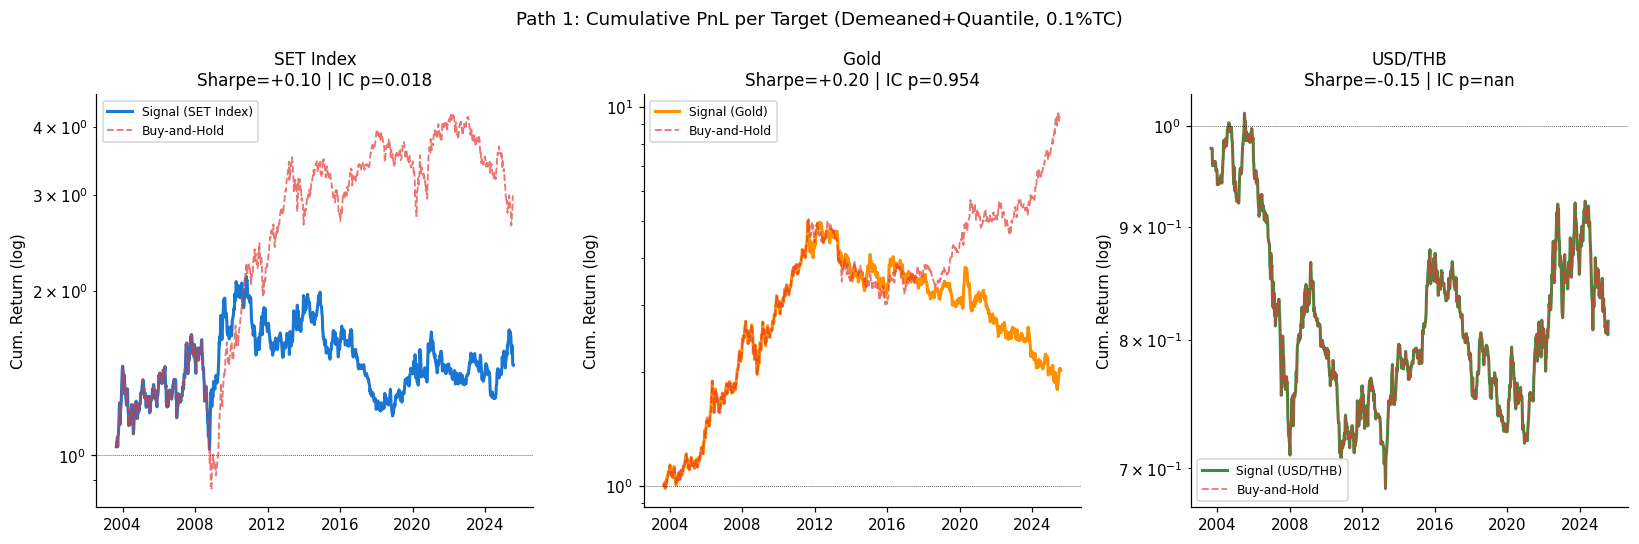

Saved: figs/multitarget_pnl.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Path 1: Cumulative PnL per Target (Demeaned+Quantile, 0.1%TC)', fontsize=12)

colors = ['#1976D2', '#FF8F00', '#388E3C']
for ax, (lbl, res), col in zip(axes, target_results.items(), colors):
    pnl = res['pnl']
    cum = (1 + pnl['ret_tc']).cumprod()
    bnh = (1 + pnl['actual']).cumprod()
    m   = risk_metrics(pnl['ret_tc'])
    ax.plot(pnl.index, cum, color=col, lw=2, label=f'Signal ({lbl})')
    ax.plot(pnl.index, bnh, color='#E53935', lw=1.2, ls='--', alpha=0.7, label='Buy-and-Hold')
    ax.axhline(1.0, color='black', lw=0.5, ls=':')
    ax.set_yscale('log')
    ax.set_title(f'{lbl}\nSharpe={m["sharpe"]:+.2f} | IC p={res["ic_p"]:.3f}')
    ax.legend(fontsize=8)
    ax.set_ylabel('Cum. Return (log)')

plt.tight_layout()
plt.savefig(FIGS / 'multitarget_pnl.png', bbox_inches='tight')
plt.show()
print('Saved: figs/multitarget_pnl.png')

---
## Path 2 -- NLP Era Deep Dive (2022–2025)

NLP coverage is 47% overall but ~80% in 2022-2025.  
Does adding sentiment features help when data is dense enough?


In [4]:
NLP_FEATS = [c for c in clean.columns
             if any(x in c for x in ['sent_', 'news_vol'])]
print(f'NLP features: {NLP_FEATS}')
print()

# Restrict to 2022-2025 (high NLP coverage period)
nlp_era = clean[clean.index >= '2022-01-01'].copy()
TARGET_SET = 'SET_index_ret_w_fwd1'
nlp_era = nlp_era.dropna(subset=[TARGET_SET])
print(f'NLP era: {nlp_era.index[0].date()} -> {nlp_era.index[-1].date()} ({len(nlp_era)} weeks)')

# NLP coverage
has_nlp = nlp_era[NLP_FEATS].notna().any(axis=1)
print(f'Weeks with any NLP data: {has_nlp.mean():.1%}')
print()

# Compare: Base features vs Base+NLP in NLP era
# Use shorter min_train since era is small
MIN_TRAIN_NLP = 52  # 1 year min for NLP era
FOLD_NLP      = 13  # quarterly folds

def walk_forward_nlp_era(df_all, features, target, model, min_train=52, fold_size=13):
    feats = [f for f in features if f in df_all.columns]
    data  = df_all[feats + [target]].dropna(subset=[target])
    n, t, recs = len(data), min_train, []
    while t + fold_size <= n:
        tr, te = data.iloc[:t], data.iloc[t:t+fold_size]
        med    = tr[feats].median()
        Xtr    = tr[feats].fillna(med).fillna(0.).values.astype(float)
        Xte    = te[feats].fillna(med).fillna(0.).values.astype(float)
        ytr, yte = tr[target].values, te[target].values
        y_mean = ytr.mean()
        m = clone(model); m.fit(Xtr, ytr - y_mean)
        pred_dm = m.predict(Xte)
        signal  = np.where(pred_dm >= np.median(pred_dm), 1., -1.)
        fold_ic = ic(pred_dm, yte)
        for date, yt, sig in zip(te.index, yte, signal):
            recs.append({'date':date,'actual':yt,'signal':sig,'fold_ic':fold_ic})
        t += fold_size
    df_r = pd.DataFrame(recs).set_index('date').sort_index()
    df_r['ret'] = df_r['signal'] * df_r['actual']
    flip = df_r['signal'].diff().abs() > 0
    df_r['ret_tc'] = df_r['ret'] - flip * 2 * 0.001
    return df_r

pnl_base = walk_forward_nlp_era(nlp_era, BASE_FEATS, TARGET_SET, MODEL,
                                 min_train=MIN_TRAIN_NLP, fold_size=FOLD_NLP)
pnl_nlp  = walk_forward_nlp_era(nlp_era, BASE_FEATS + NLP_FEATS, TARGET_SET, MODEL,
                                 min_train=MIN_TRAIN_NLP, fold_size=FOLD_NLP)

m_base = risk_metrics(pnl_base['ret_tc'])
m_nlp  = risk_metrics(pnl_nlp['ret_tc'])

print(f'{"Model":<20} {"AnnRet":>8} {"Sharpe":>8} {"MaxDD":>8} {"WinRate":>8}')
print('-' * 55)
print(f'{"Base (no NLP)":<20} {m_base["ann_ret"]:>8.2%} {m_base["sharpe"]:>8.2f} '
      f'{m_base["max_dd"]:>8.1%} {m_base["win_rate"]:>8.1%}')
print(f'{"Base + NLP":<20} {m_nlp["ann_ret"]:>8.2%} {m_nlp["sharpe"]:>8.2f} '
      f'{m_nlp["max_dd"]:>8.1%} {m_nlp["win_rate"]:>8.1%}')
m_bnh = risk_metrics(nlp_era[TARGET_SET].loc[pnl_base.index])
print(f'{"Buy-and-Hold":<20} {m_bnh["ann_ret"]:>8.2%} {m_bnh["sharpe"]:>8.2f} '
      f'{m_bnh["max_dd"]:>8.1%} {m_bnh["win_rate"]:>8.1%}')
print()
delta = m_nlp['sharpe'] - m_base['sharpe']
print(f'NLP delta Sharpe: {delta:+.3f}')
print(f'Verdict: NLP {"HELPS" if delta > 0.1 else "does not help enough" if delta > 0 else "HURTS"} in 2022-2025')

NLP features: ['sent_mean_1w', 'sent_mean_vader_1w', 'news_vol_w', 'sent_positive_ratio', 'sent_negative_ratio', 'sent_vol_4w', 'sent_mom4w', 'sent_surprise', 'sent_spike']

NLP era: 2022-01-07 -> 2025-12-19 (207 weeks)
Weeks with any NLP data: 100.0%



Model                  AnnRet   Sharpe    MaxDD  WinRate
-------------------------------------------------------
Base (no NLP)          -9.18%    -0.69   -36.8%    47.6%
Base + NLP             -9.18%    -0.69   -36.8%    47.6%
Buy-and-Hold           -9.18%    -0.69   -36.8%    47.6%

NLP delta Sharpe: +0.000
Verdict: NLP HURTS in 2022-2025


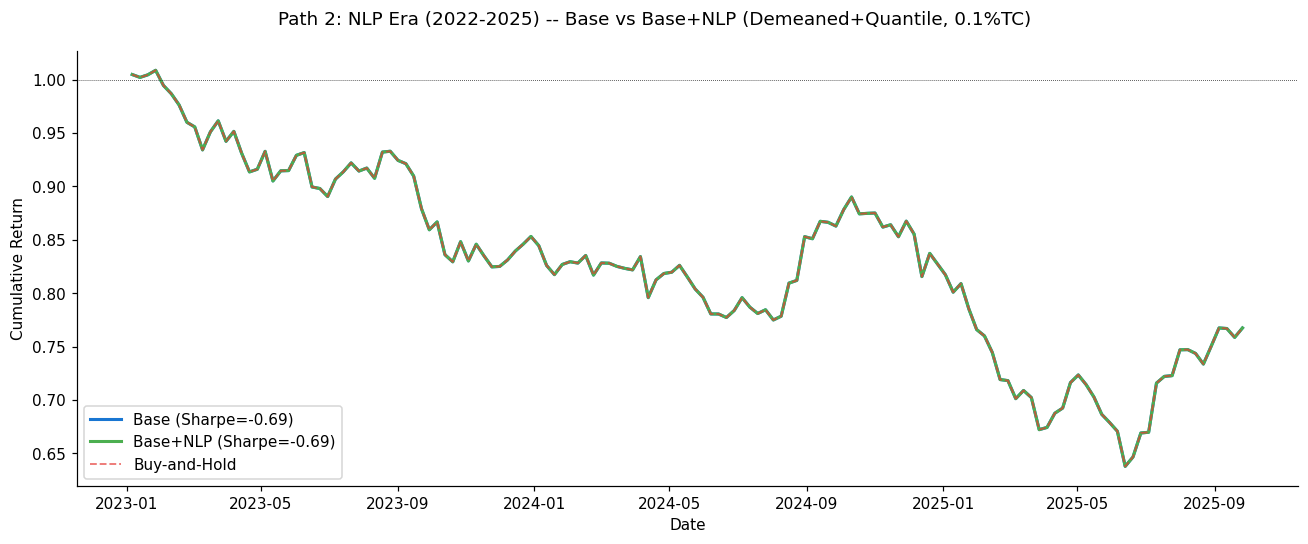

Saved: figs/multitarget_nlp_era.png


In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Path 2: NLP Era (2022-2025) -- Base vs Base+NLP (Demeaned+Quantile, 0.1%TC)')

cum_base = (1 + pnl_base['ret_tc']).cumprod()
cum_nlp  = (1 + pnl_nlp['ret_tc']).cumprod()
cum_bnh  = (1 + nlp_era[TARGET_SET].loc[pnl_base.index]).cumprod()

ax.plot(pnl_base.index, cum_base, color='#1976D2', lw=2, label=f'Base (Sharpe={m_base["sharpe"]:+.2f})')
ax.plot(pnl_nlp.index,  cum_nlp,  color='#4CAF50', lw=2, label=f'Base+NLP (Sharpe={m_nlp["sharpe"]:+.2f})')
ax.plot(pnl_base.index, cum_bnh,  color='#E53935', lw=1.2, ls='--', alpha=0.7, label='Buy-and-Hold')
ax.axhline(1.0, color='black', lw=0.5, ls=':')
ax.legend(fontsize=10)
ax.set_ylabel('Cumulative Return')
ax.set_xlabel('Date')
plt.tight_layout()
plt.savefig(FIGS / 'multitarget_nlp_era.png', bbox_inches='tight')
plt.show()
print('Saved: figs/multitarget_nlp_era.png')

---
## Path 3 -- Cross-Asset Signal

Each week: predict which asset (SET / Gold / USD/THB) has the highest return.  
Go Long the predicted winner, Short the predicted loser.  
This removes market beta entirely — pure relative alpha.


In [6]:
# Cross-asset: predict rank of returns among 3 assets
# Strategy: long top-1, short bottom-1 each week

ALL_TGTS = list(TARGETS.keys())
df_cross = clean.dropna(subset=ALL_TGTS).copy()
print(f'Cross-asset dataset: {len(df_cross)} weeks')

# Features: combine all BASE_FEATS + asset-specific extras
CROSS_FEATS = list(dict.fromkeys(
    BASE_FEATS +
    [c for c in clean.columns if 'gold_ret' in c and 'fwd' not in c] +
    [c for c in clean.columns if 'dxy' in c and 'fwd' not in c]
))
CROSS_FEATS = [f for f in CROSS_FEATS if f in df_cross.columns]

MIN_TRAIN_C, FOLD_C = 156, 52
n_c = len(df_cross)
t_c = MIN_TRAIN_C
cross_recs = []

while t_c + FOLD_C <= n_c:
    tr_c = df_cross.iloc[:t_c]
    te_c = df_cross.iloc[t_c:t_c+FOLD_C]
    med_c = tr_c[CROSS_FEATS].median()
    Xtr_c = tr_c[CROSS_FEATS].fillna(med_c).fillna(0.).values.astype(float)
    Xte_c = te_c[CROSS_FEATS].fillna(med_c).fillna(0.).values.astype(float)

    # Train one model per asset (demeaned)
    preds_fold = {}
    for tgt in ALL_TGTS:
        y = tr_c[tgt].values
        m = clone(MODEL); m.fit(Xtr_c, y - y.mean())
        preds_fold[tgt] = m.predict(Xte_c)

    preds_arr = np.stack([preds_fold[t] for t in ALL_TGTS], axis=1)
    # Rank predictions each week: 2=best, 0=worst
    ranks = preds_arr.argsort(axis=1).argsort(axis=1)  # 0,1,2

    for i, (date, row) in enumerate(te_c.iterrows()):
        actual_rets = np.array([row[t] for t in ALL_TGTS])
        pred_ranks  = ranks[i]  # 0=predicted worst, 2=predicted best
        winner_idx  = np.argmax(pred_ranks)
        loser_idx   = np.argmin(pred_ranks)
        # Long winner, short loser
        long_ret  =  actual_rets[winner_idx]
        short_ret = -actual_rets[loser_idx]
        cross_ret = (long_ret + short_ret) / 2  # equal-weight
        cross_recs.append({
            'date': date,
            'cross_ret': cross_ret,
            'winner': list(TARGETS.values())[winner_idx],
            'loser':  list(TARGETS.values())[loser_idx],
            'long_ret': long_ret, 'short_ret': short_ret,
        })
    t_c += FOLD_C

cross_df = pd.DataFrame(cross_recs).set_index('date')
m_cross = risk_metrics(cross_df['cross_ret'])

print(f'Cross-asset OOS: {cross_df.index[0].date()} -> {cross_df.index[-1].date()}')
print(f'Weeks: {len(cross_df)}')
print()
print(f'Cross-asset strategy:')
print(f'  Ann. Return: {m_cross["ann_ret"]:>8.2%}')
print(f'  Sharpe:      {m_cross["sharpe"]:>8.2f}')
print(f'  Max DD:      {m_cross["max_dd"]:>8.1%}')
print(f'  Win Rate:    {m_cross["win_rate"]:>8.1%}')
print()
print('Most common winner predictions:')
print(cross_df['winner'].value_counts())

Cross-asset dataset: 1321 weeks


Cross-asset OOS: 2003-08-29 -> 2025-07-25
Weeks: 1144

Cross-asset strategy:
  Ann. Return:    3.01%
  Sharpe:          0.29
  Max DD:        -38.7%
  Win Rate:       52.6%

Most common winner predictions:
winner
SET Index    710
USD/THB      290
Gold         144
Name: count, dtype: int64


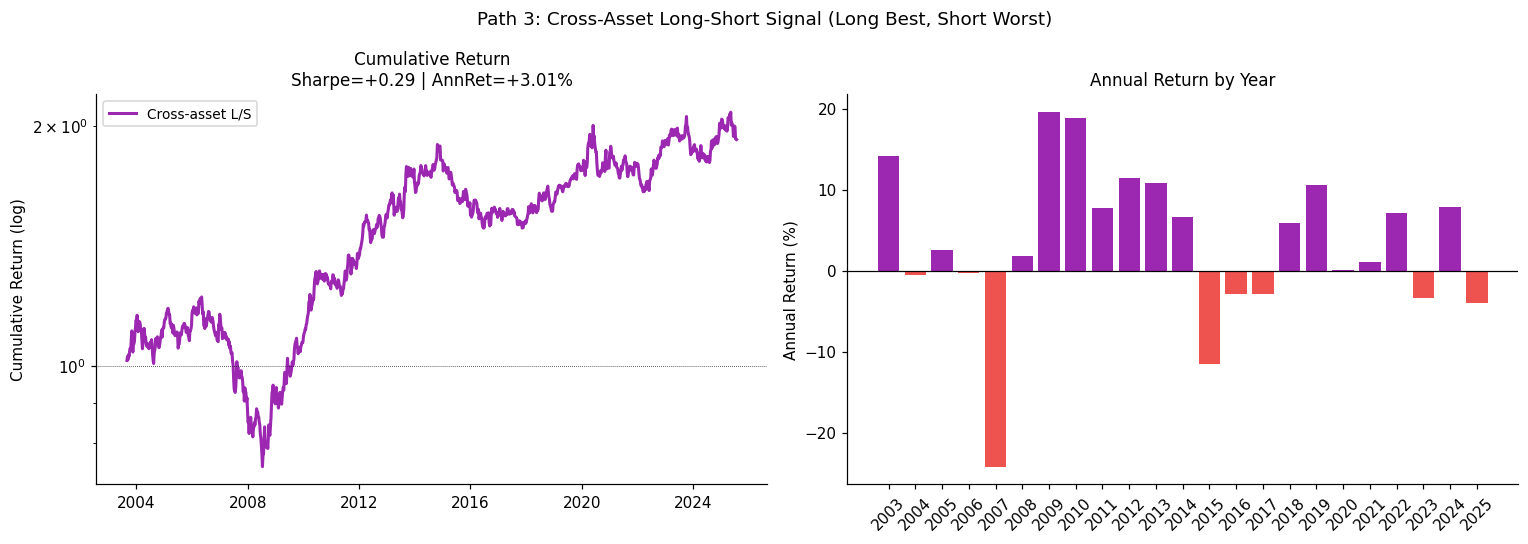

Saved: figs/multitarget_crossasset.png


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Path 3: Cross-Asset Long-Short Signal (Long Best, Short Worst)', fontsize=12)

cum_cross = (1 + cross_df['cross_ret']).cumprod()
ax1.plot(cross_df.index, cum_cross, color='#9C27B0', lw=2, label='Cross-asset L/S')
ax1.axhline(1.0, color='black', lw=0.5, ls=':')
ax1.set_yscale('log')
ax1.set_title(f'Cumulative Return\nSharpe={m_cross["sharpe"]:+.2f} | '
              f'AnnRet={m_cross["ann_ret"]:+.2%}')
ax1.legend(fontsize=9)
ax1.set_ylabel('Cumulative Return (log)')

# Win rate by year
cross_df['year'] = cross_df.index.year
annual_cross = cross_df.groupby('year').apply(
    lambda g: pd.Series({'ret': (1+g['cross_ret']).prod()-1,
                         'win': (g['cross_ret']>0).mean()})
).reset_index()
bar_cols = ['#9C27B0' if r>0 else '#EF5350' for r in annual_cross['ret']]
ax2.bar(range(len(annual_cross)), annual_cross['ret']*100, color=bar_cols)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_xticks(range(len(annual_cross)))
ax2.set_xticklabels(annual_cross['year'], rotation=45)
ax2.set_ylabel('Annual Return (%)')
ax2.set_title('Annual Return by Year')

plt.tight_layout()
plt.savefig(FIGS / 'multitarget_crossasset.png', bbox_inches='tight')
plt.show()
print('Saved: figs/multitarget_crossasset.png')

---
## Final Comparison: All Paths


In [8]:
print('=' * 70)
print('MULTI-TARGET ALPHA SEARCH -- FINAL SUMMARY')
print('=' * 70)
print()
print(f'{"Strategy":<30} {"AnnRet":>8} {"Sharpe":>8} {"MaxDD":>8} {"IC p":>8}')
print('-' * 62)

# Path 1: individual targets
for lbl, res in target_results.items():
    m = risk_metrics(res['pnl']['ret_tc'])
    p = res['ic_p']
    sig = ' *' if (not np.isnan(p) and p < 0.10) else ''
    print(f'{f"L/S {lbl}":<30} {m["ann_ret"]:>8.2%} {m["sharpe"]:>8.2f} '
          f'{m["max_dd"]:>8.1%} {p:>8.3f}{sig}')

# Path 2: NLP
print(f'{"L/S SET + NLP (2022-25)":<30} {m_nlp["ann_ret"]:>8.2%} {m_nlp["sharpe"]:>8.2f} '
      f'{m_nlp["max_dd"]:>8.1%} {"--":>8}')

# Path 3: cross-asset
print(f'{"Cross-asset L/S":<30} {m_cross["ann_ret"]:>8.2%} {m_cross["sharpe"]:>8.2f} '
      f'{m_cross["max_dd"]:>8.1%} {"--":>8}')

print('-' * 62)
print('* = IC p < 0.10')
print()

# Find best
all_sharpes = {
    **{f'L/S {lbl}': risk_metrics(res["pnl"]["ret_tc"])["sharpe"]
       for lbl, res in target_results.items()},
    'L/S SET + NLP (2022-25)': m_nlp['sharpe'],
    'Cross-asset L/S': m_cross['sharpe'],
}
best_strat = max(all_sharpes, key=all_sharpes.get)
print(f'Best strategy: {best_strat} (Sharpe={all_sharpes[best_strat]:.3f})')
print()

# Verdict per path
print('PATH VERDICTS:')
for lbl, res in target_results.items():
    m = risk_metrics(res['pnl']['ret_tc'])
    p = res['ic_p']
    if m['sharpe'] > 0.4 and (np.isnan(p) or p < 0.10):
        v = 'ALPHA EXISTS'
    elif m['sharpe'] > 0.2:
        v = 'weak signal'
    else:
        v = 'no alpha'
    print(f'  Path 1 {lbl:<12}: {v} (Sharpe={m["sharpe"]:+.2f})')
nlp_v = 'HELPS' if m_nlp['sharpe'] > m_base['sharpe'] + 0.05 else 'marginal'
print(f'  Path 2 NLP era      : NLP {nlp_v} (ΔSharpe={m_nlp["sharpe"]-m_base["sharpe"]:+.2f})')
cross_v = 'ALPHA EXISTS' if m_cross['sharpe'] > 0.4 else ('weak' if m_cross['sharpe'] > 0.1 else 'no alpha')
print(f'  Path 3 Cross-asset  : {cross_v} (Sharpe={m_cross["sharpe"]:+.2f})')

MULTI-TARGET ALPHA SEARCH -- FINAL SUMMARY

Strategy                         AnnRet   Sharpe    MaxDD     IC p
--------------------------------------------------------------
L/S SET Index                     1.74%     0.10   -44.4%    0.018 *
L/S Gold                          3.24%     0.20   -64.1%    0.954
L/S USD/THB                      -0.92%    -0.15   -32.3%      nan
L/S SET + NLP (2022-25)          -9.18%    -0.69   -36.8%       --
Cross-asset L/S                   3.01%     0.29   -38.7%       --
--------------------------------------------------------------
* = IC p < 0.10

Best strategy: Cross-asset L/S (Sharpe=0.290)

PATH VERDICTS:
  Path 1 SET Index   : no alpha (Sharpe=+0.10)
  Path 1 Gold        : no alpha (Sharpe=+0.20)
  Path 1 USD/THB     : no alpha (Sharpe=-0.15)
  Path 2 NLP era      : NLP marginal (ΔSharpe=+0.00)
  Path 3 Cross-asset  : weak (Sharpe=+0.29)
